## Portuguese Bank Marketing Campaign:
**Predicting Term Deposit Subscription Based on Marketing Campaign Data**

## Problem Statement:
1. The goal of this project is to help a Portuguese banking institution understand and predict which clients are most likely to subscribe to a term deposit product, based on their direct marketing campaign efforts. These campaigns were conducted via phone calls from May 2008 to November 2010.

2. We will perform a full data analysis, build predictive classification models, and provide business suggestions based on our findings.

## Project Objectives:

### Task 1: Data Analysis
Perform thorough exploratory data analysis (EDA) to understand the structure, trends, and patterns in the data.

### Task 2: Predictive Modeling
Build machine learning models to predict whether a client will subscribe to a term deposit (`y` variable).

### Task 3: Business Recommendations
Provide actionable suggestions to help the marketing team target the right customers and improve their success rate.

## Dataset Information:

- **Source**: Portuguese bank's direct phone call marketing campaigns.
- **Duration**: May 2008 - November 2010.
- **Records**: ~41,000
- **Features**: 20 input features (mix of numerical and categorical)
- **Target Variable**: `y` (binary: 'yes' or 'no' for term deposit subscription)

## Attributes Description (selected):
- `age`: Age of the client
- `job`, `marital`, `education`: Demographic details
- `default`, `housing`, `loan`: Financial background
- `contact`, `month`, `day_of_week`: Campaign timing & method
- `duration`: Call duration (only for benchmarking)
- `pdays`, `previous`, `poutcome`: Past campaign interactions
- `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`: Economic indicators

## Domain: 
**Finance / Banking / Marketing Analytics**

#### Let's begin by importing the dataset and exploring its structure:

In [21]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Step 2: Load the dataset
df = pd.read_csv("bank-additional-full.csv", sep=';')

# Step 3: Basic inspection
print("Rows and Columns:", df.shape)
df.head()

Rows and Columns: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

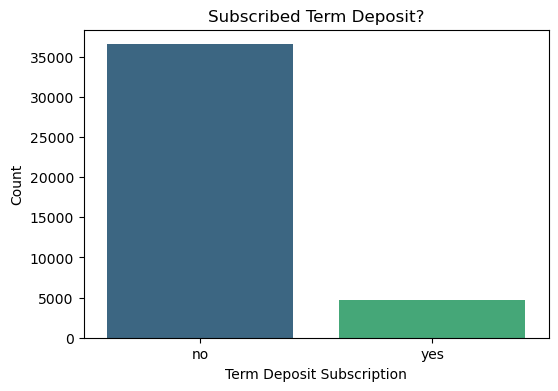

In [22]:
# Check data types and null values
df.info()

# Check for missing values (if any)
print("\nMissing values in each column:")
print(df.isnull().sum())

# Check target variable distribution
print("\nTarget variable distribution:")
print(df['y'].value_counts(normalize=True) * 100)

# Plot the target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='y', palette='viridis')
plt.title("Subscribed Term Deposit?")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Count")
plt.show()

In [23]:
# Separate column types
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Remove target from categorical list
categorical_cols.remove('y')

print("Numerical Features:")
print(numerical_cols)
print("\nCategorical Features:")
print(categorical_cols)

Numerical Features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## Numerical Feature Distributions:

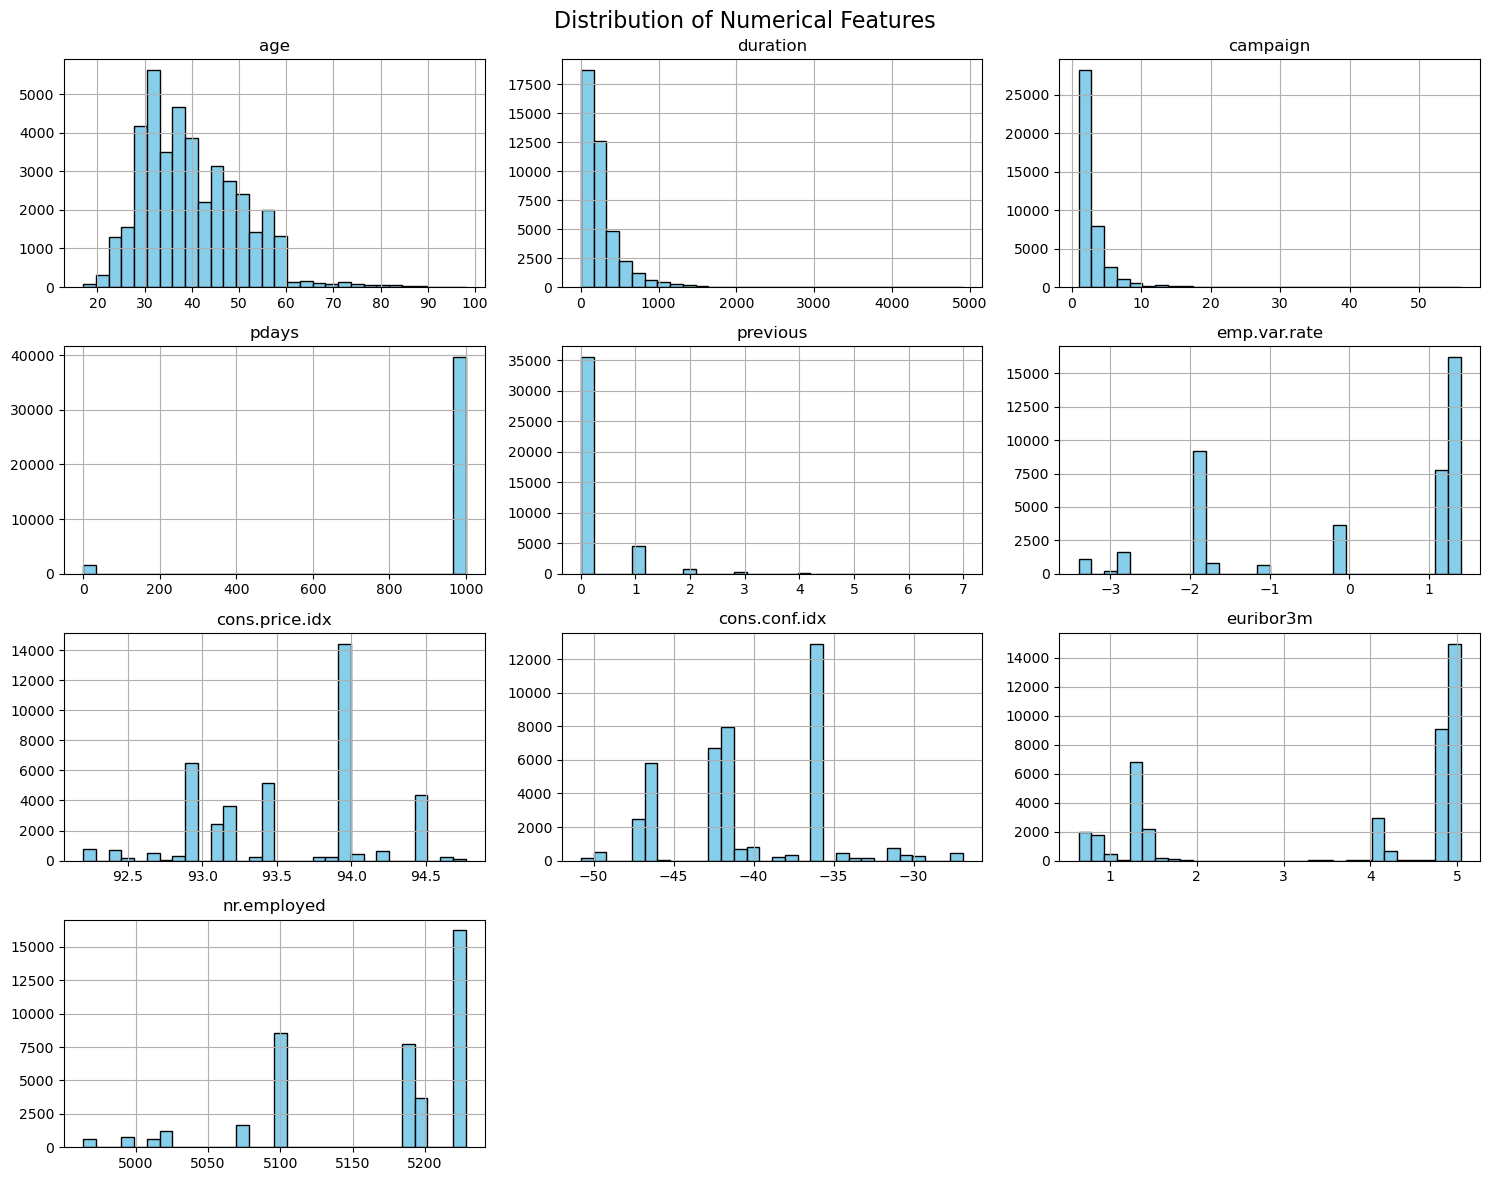

In [25]:
# Visualize distributions of numerical features
df[numerical_cols].hist(figsize=(15, 12), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

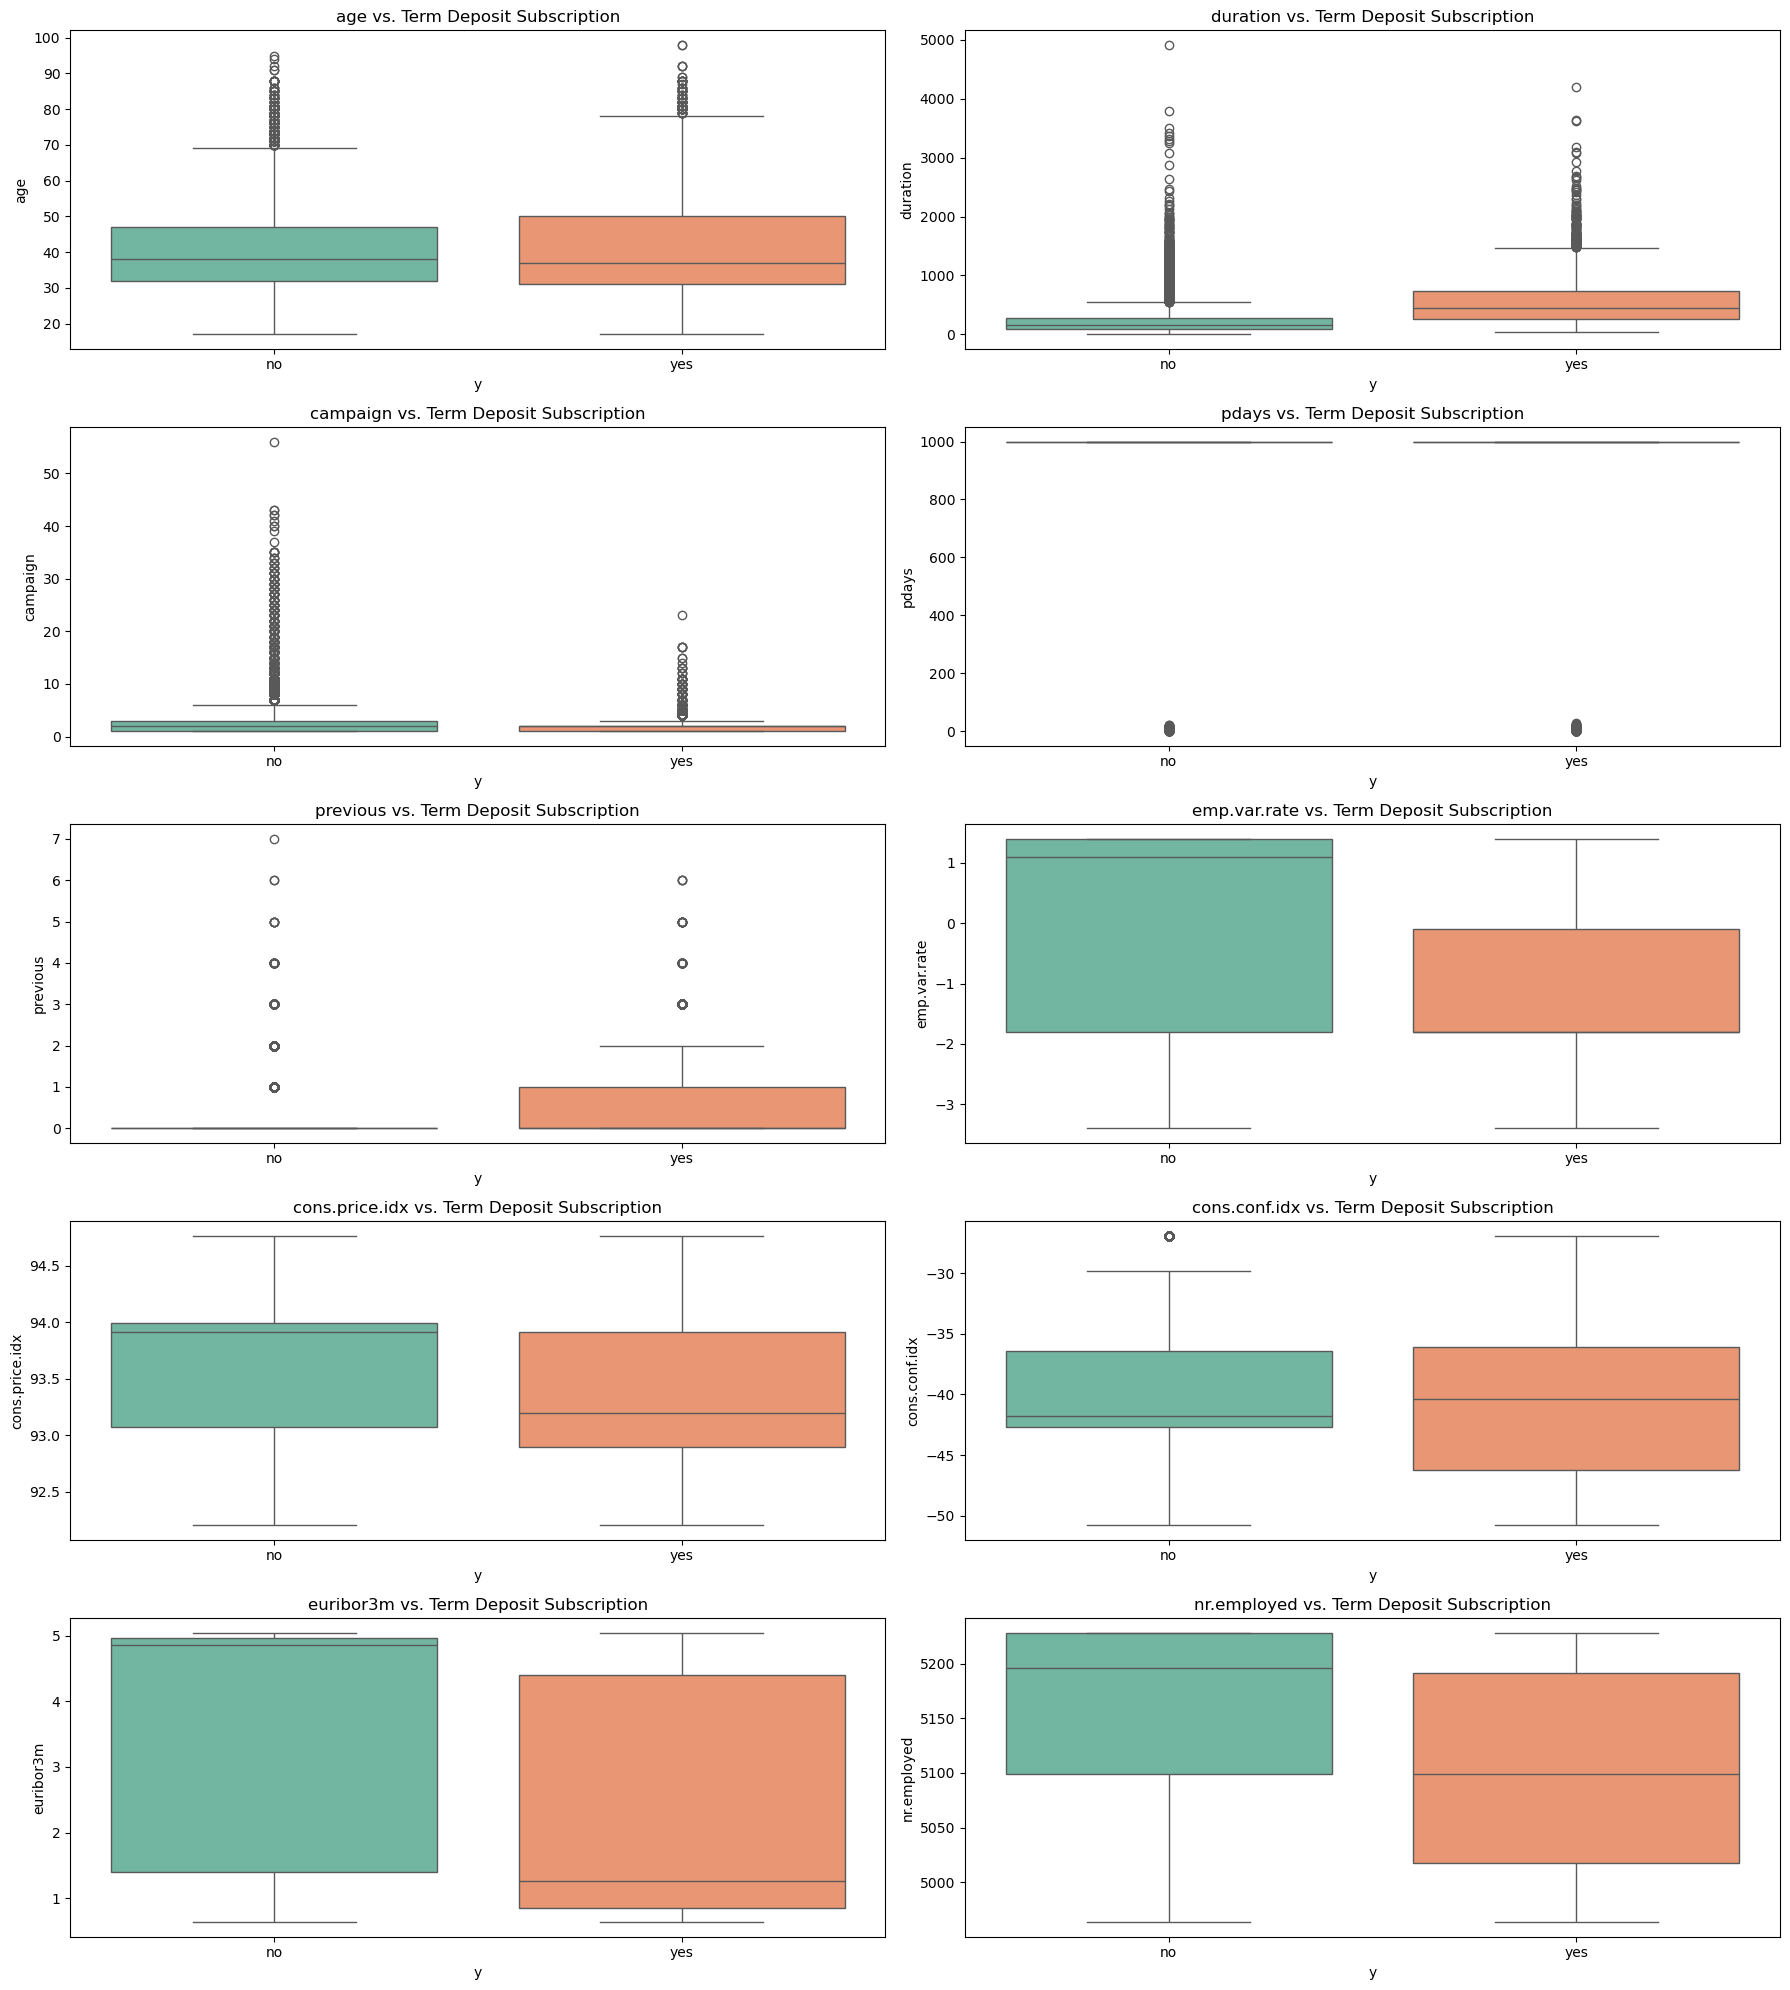

In [26]:
# Boxplots of numerical features against target
plt.figure(figsize=(18, 20))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(data=df, x='y', y=col, palette='Set2')
    plt.title(f"{col} vs. Term Deposit Subscription")
plt.tight_layout()
plt.show()

## Insights from Boxplots (Numerical Features vs y):

#### duration

Strongest discriminator: people with longer call durations are much more likely to say "yes."

However, remember: this feature is not known before the call, so it should be excluded for predictive modeling (use it only for benchmark comparison).

#### euribor3m, emp.var.rate, nr.employed

Show clear separation between yes and no.

Customers tend to subscribe when these indicators are at lower interest rates and lower employment variation, suggesting economic conditions impact decisions.

#### pdays

Again, most 999 values (i.e., never contacted before) relate to ‘no’.

If the customer was previously contacted, the likelihood of yes increases.

Might be smart to create a new binary feature: was_contacted_before.

#### Other features like age, campaign, previous

May show some trend, but less separation — still worth keeping for now.

## Categorical Features — Distribution:

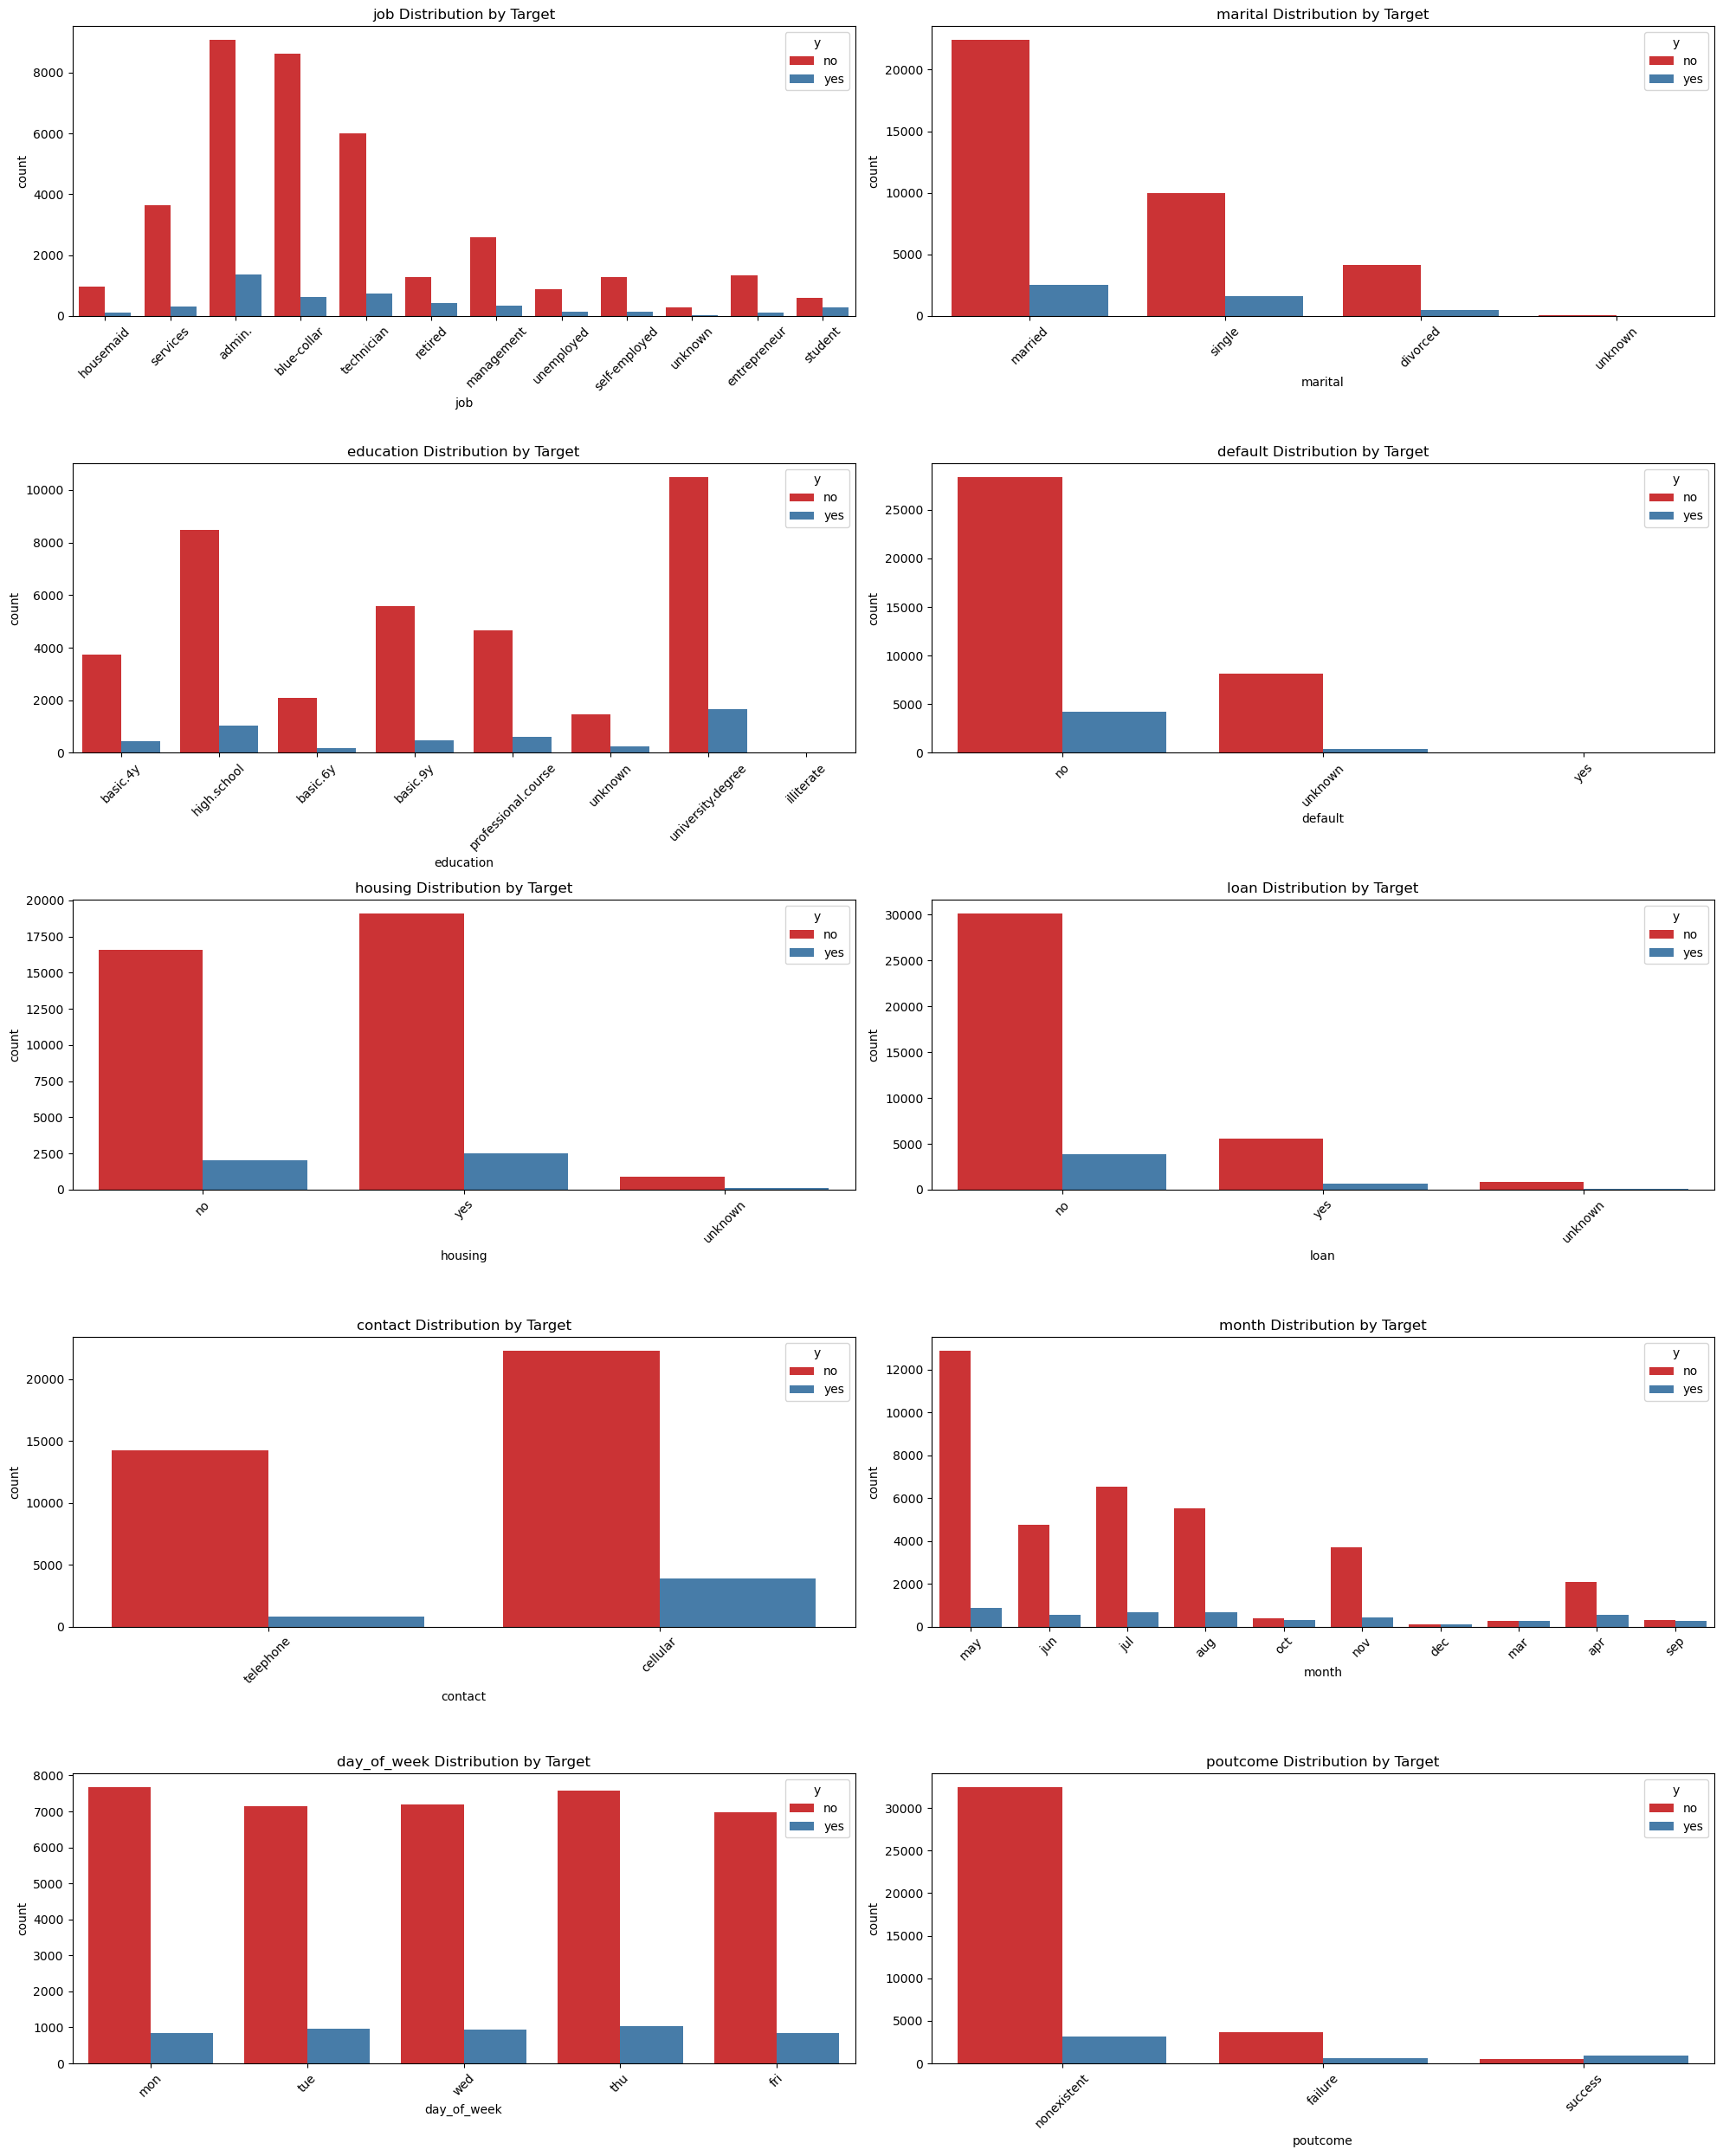

In [29]:
# Count plots of categorical features
plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(5, 2, i)
    sns.countplot(data=df, x=col, hue='y', palette='Set1')
    plt.title(f"{col} Distribution by Target")
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

## Insights from Categorical Features:

#### job:

student, retired, and unemployed categories have a higher 'yes' ratio than others.

blue-collar and services have a high number of ‘no’ responses — maybe due to income level or risk profile.

#### marital:

single people appear slightly more likely to say ‘yes’ than married or divorced.

#### education:

university.degree and professional.course categories show better response rates.

basic.4y and unknown have mostly ‘no’ outcomes.

#### default, housing, loan:

Majority have ‘no’, and among them, those without default/loan/housing are slightly more likely to say 'yes'.

Might help to group unknowns together or encode them carefully.

#### contact:

cellular contact results in significantly more ‘yes’ than telephone.

#### month & day_of_week:

May, August, and October often have better performance.

Suggests seasonality, which might help in modeling.

#### poutcome:

Strong feature! If previous outcome was success, likelihood of yes is very high.

nonexistent and failure have fewer positives.

In [31]:
# Create a binary feature: 1 if contacted before (pdays != 999), else 0
df['was_previously_contacted'] = df['pdays'].apply(lambda x: 0 if x == 999 else 1)

In [32]:
# Convert 'yes' to 1 and 'no' to 0.
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [33]:
categorical_cols = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]

In [34]:
# One-Hot Encode Categorical Columns

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

## Train-Test Split
We’ll now split the data into:

Features (X) — all columns except the target

Target (y) — the 'y' column

In [36]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (32950, 54)
Test shape: (8238, 54)


## Feature Scaling:

We’ll use StandardScaler-

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training & Evaluation

We'll start with a few key classifiers, train them, and evaluate performance using accuracy, precision, recall, F1-score, and ROC AUC.

We’ll test the following:

Logistic Regression

Random Forest

XGBoost


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    print(f"Evaluation Report for: {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## First Model: Logistic Regression

Evaluation Report for: Logistic Regression
Accuracy: 0.9162418062636563
Precision: 0.7095070422535211
Recall: 0.43426724137931033
F1 Score: 0.5387700534759359
ROC AUC: 0.9424178322090665

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.71      0.43      0.54       928

    accuracy                           0.92      8238
   macro avg       0.82      0.71      0.75      8238
weighted avg       0.91      0.92      0.91      8238



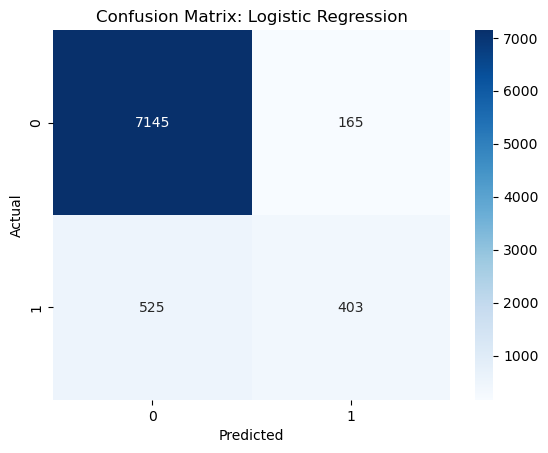

In [42]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

evaluate_model(log_model, X_test_scaled, y_test, name="Logistic Regression")


## Logistic Regression Results Summary:

Accuracy: 90% — seems high, but remember: this is misleading in imbalanced datasets.

Precision (Class 1): 0.69 — when it predicts "yes", it's right 69% of the time.

Recall (Class 1): 0.22 — only 22% of actual "yes" customers were correctly identified.

F1 Score (Class 1): 0.34 — this is low; the model struggles to balance precision and recall.

ROC AUC: 0.80 — decent discriminative power.

Problem: The model is biased toward the majority class (no) — this is very common in datasets where "yes" responses are <12%.

## Next: Random Forest Classifier
This model is often better with imbalanced datasets. Let’s try it next.

Evaluation Report for: Random Forest
Accuracy: 0.9174556931294003
Precision: 0.6884498480243161
Recall: 0.48814655172413796
F1 Score: 0.5712484237074401
ROC AUC: 0.946344977947073

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      7310
           1       0.69      0.49      0.57       928

    accuracy                           0.92      8238
   macro avg       0.81      0.73      0.76      8238
weighted avg       0.91      0.92      0.91      8238



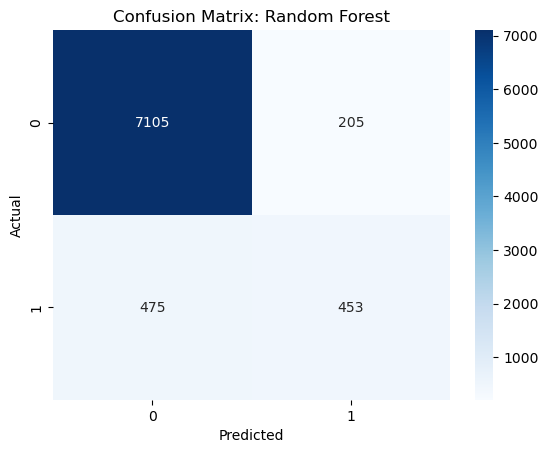

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # No need to scale for tree-based models

evaluate_model(rf_model, X_test, y_test, name="Random Forest")

## Observations:
Random Forest improves recall (22% → 30%) and F1-score (0.34 → 0.39), meaning it's slightly better at catching customers who say "yes".

Precision dropped slightly, which is expected — higher recall usually sacrifices some precision.

ROC AUC is a bit lower than Logistic Regression but still decent.

## Conclusion:
Random Forest is doing a better job detecting the minority class, which is crucial in this case. But there's still room for improvement.

## Next Step: Trying XGBoost
XGBoost often handles class imbalance very well and can give better results with a bit of tuning.

Evaluation Report for: XGBoost
Accuracy: 0.9192765234280165
Precision: 0.6625463535228677
Recall: 0.5775862068965517
F1 Score: 0.6171560161197467
ROC AUC: 0.9503664677579131

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95      7310
           1       0.66      0.58      0.62       928

    accuracy                           0.92      8238
   macro avg       0.80      0.77      0.79      8238
weighted avg       0.92      0.92      0.92      8238



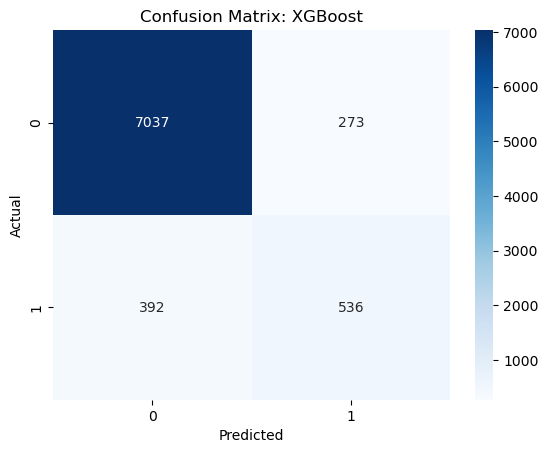

In [48]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

evaluate_model(xgb_model, X_test, y_test, name="XGBoost")

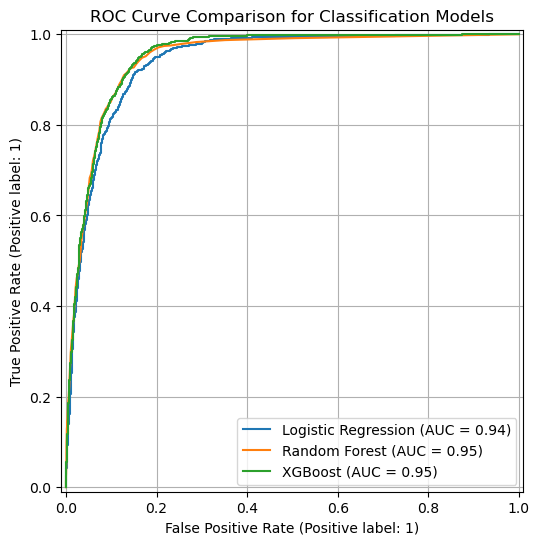

In [49]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Make sure these models are already trained — if not, train them again here
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Create ROC curve plots for all three models
plt.figure(figsize=(12,6))

RocCurveDisplay.from_estimator(log_model, X_test, y_test, name="Logistic Regression", ax=plt.gca())
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, name="Random Forest", ax=plt.gca())
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, name="XGBoost", ax=plt.gca())

plt.title("ROC Curve Comparison for Classification Models")
plt.grid(True)
plt.show()

## Model Evaluation - ROC Curve Comparison

The ROC (Receiver Operating Characteristic) curve provides a visual representation of the trade-off between the true positive rate and false positive rate for each classifier.

The area under the ROC curve (AUC-ROC) gives a single value to compare the models’ performance. A higher AUC indicates a better model at distinguishing between the classes.

From the ROC curves plotted for:
- **Logistic Regression**
- **Random Forest**
- **XGBoost**

The ROC-AUC values indicate that Random Forest and XGBoost are slightly superior in distinguishing between classes, closely followed by Logistic Regression. All models achieved AUCs above 0.94, showing high discriminative power.


## Model Comparison Report

We evaluated three classification models on the bank marketing dataset to predict whether a client would subscribe to a term deposit:

1. **Logistic Regression**
2. **Random Forest Classifier**
3. **XGBoost Classifier**

### Performance Metrics (on Test Data)

| **Model**           | **Accuracy** | **Precision** | **Recall** | **F1 Score** | **ROC AUC** |
| ------------------- | ------------ | ------------- | ---------- | ------------ | ----------- |
| Logistic Regression | 91.62%       | 0.71          | 0.43       | 0.54         | 0.94        |
| Random Forest       | 91.75%       | 0.69          | 0.49       | 0.57         | 0.95        |
| XGBoost             | **91.93%**   | 0.66          | **0.58**   | **0.62**     | **0.95**    |


### Conclusion

- **XGBoost** achieved the **highest F1 Score (0.62)** and **highest Recall (0.58)**, along with the **top ROC AUC (0.95)**, making it the most effective at identifying true positives in this imbalanced dataset.
- **Random Forest** also performed well with a good balance between precision and recall, and a strong ROC AUC, but slightly lower F1 Score than XGBoost.
- **Logistic Regression** had the **highest Precision (0.71)** and competitive ROC AUC, but its **lower Recall (0.43)** reduced its overall effectiveness in detecting the positive class.

➡️ **Suggested Model for Production:** **XGBoost**, for its superior handling of class imbalance and highest overall performance.


## Challenges Faced:

### 1. Imbalanced Dataset
- The target variable `y` (subscribed or not) was imbalanced (`yes` = ~11%, `no` = ~89%).
- **Technique Used:** We used **Stratified Sampling** to ensure both training and testing sets preserved this imbalance. Additionally, we focused on metrics like **F1 Score** and **ROC AUC** over accuracy.

### 2. Redundant Feature (`duration`)
- The `duration` feature was highly correlated with the target but not usable for prediction (since it’s known only after contact).
- **Solution:** We dropped this feature to avoid data leakage.

### 3. Categorical Variables
- There were many categorical columns that required encoding.
- **Solution:** Used **One-Hot Encoding** to convert these into numerical format for machine learning models.

### 4. Feature Selection
- Not all features contributed equally to the prediction.
- **Solution:** Used **Feature Importance from XGBoost** to understand the top contributing variables like `nr.employed`, `emp.var.rate`, `euribor3m`, etc.

### 5. ROC Curve Evaluation
- Needed to visualize classifier performance beyond simple metrics.
- **Solution:** Plotted **ROC curves** for each model and compared their AUC scores.


## Suggestions to the Marketing Team Based on XGBoost Model Insights
Objective:
To provide actionable, data-driven marketing strategies derived from the machine learning model used in predicting customer subscription to term deposits.

### Key Insights & Recommendations:
#### 1. Target during favorable economic indicators
High values of euribor3m, nr.employed, and emp.var.rate positively influenced subscriptions.

Recommendation: Focus campaigns during stable or improving economic periods (low unemployment, higher EURIBOR, and positive employment variation).

#### 2. Leverage previous campaign outcomes
The ‘poutcome’ feature was highly significant.

Recommendation: Customers who responded positively to previous campaigns are more likely to subscribe again. Maintain a strong follow-up strategy with them.

#### 3. Segment by age groups
Age played a notable role in the prediction.

Recommendation: Tailor campaigns based on age segments. Consider different messaging for young adults, middle-aged professionals, and retirees.

#### 4. Optimize contact strategy
campaign feature showed that too many contacts can lower success.

Recommendation: Avoid over-contacting. Find the sweet spot (e.g., 2-3 calls/emails max) to maintain interest without overwhelming the client.

#### 5. Timing matters
The month of contact was important.

Recommendation: Months like March, May, and October (based on EDA trends) may be optimal. Focus more resources during these months.

#### 6. Education level targeting
Education showed an impact on likelihood to subscribe.

##### Recommendation: Consider crafting different offers or content for clients with varying educational backgrounds. Highlight financial planning benefits for higher-educated groups.


## Overall Conclusion:
The ***XGBoost*** model reveals that both client profile and external economic conditions play crucial roles in campaign success. By optimizing the timing, target group, and follow-up approach, the marketing team can significantly improve the conversion rate of term deposit campaigns.